# Cryptocurrency Closing Price Prediction Using Random Forest

## Overview
This project aims to predict the daily closing price of a cryptocurrency using the Random Forest regression algorithm based on historical market data. The model is trained using historical features and evaluated using standard regression metrics.

# Prep

In [ ]:
# If you are using Google Colab, uncomment the following lines to mount Google Drive
# from google.colab import drive
# //
# from google.colab import drive
# drive.mount('/content/drive')
# //

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import DateFormatter
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [2]:
# === Load dataset ===
# if u use google collab use this following line
# dataset_path = '/content/drive/MyDrive/Tugas Akhir/S1/Crypto/Dataset/ETH_IDR_365days.csv'

eth = pd.read_csv("ETH_IDR_365days.csv")

if 'date' in eth.columns:
    eth['date'] = pd.to_datetime(eth['date'])

eth.head(10)

,date,high,low,close
0,2024-11-03,39546745.62,38319076.65,38899670.55
1,2024-11-04,39130524.10,37439471.56,37904195.46
2,2024-11-05,38886351.62,37873210.25,38215973.84
3,2024-11-06,43188130.35,38191418.97,43188130.35
4,2024-11-07,45161214.07,42927572.48,44967483.58
5,2024-11-08,46376847.92,45174022.79,46366760.06
6,2024-11-09,49155159.49,46443762.28,49155159.49
7,2024-11-10,50726252.69,48696721.32,49744007.38
8,2024-11-11,52963485.96,49173347.82,52963485.96
9,2024-11-12,53619573.44,51181152.61,51798244.44


# Feature enginering & Preprocessing

In [3]:
# 1. Lag harga penutupan
eth["close_lag1"] = eth["close"].shift(1)

# 2. Daily return (%)
eth['daily_return'] = eth['close'].pct_change() * 100

# 3. SMA & EMA 14
eth['sma_14'] = eth['close'].rolling(window=14).mean()
eth['ema_14'] = eth['close'].ewm(span=14, adjust=False).mean()

# 4. Bollinger Bands upper
eth['bb_mid'] = eth['sma_14']
eth['bb_std'] = eth['close'].rolling(window=14).std()
eth['bb_upper'] = eth['bb_mid'] + (2 * eth['bb_std'])

# 7. RSI 14 hari
delta = eth['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
eth['rsi_14'] = 100 - (100 / (1 + rs))

# 8. True Range dan ATR 14 (dengan high, low, close)
prev_close = eth['close'].shift(1)
tr1 = eth['high'] - eth['low']
tr2 = (eth['high'] - prev_close).abs()
tr3 = (eth['low'] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
eth['atr_14'] = true_range.rolling(14).mean()

# === Target: Return t+1 ===
eth['target_return'] = eth['close'].pct_change().shift(-1) * 100

# === Drop NaN & reset index ===
eth_processed = eth.dropna().reset_index(drop=True)

eth_processed.head(10)

,date,high,low,close,close_lag1,daily_return,sma_14,ema_14,bb_mid,bb_std,bb_upper,rsi_14,atr_14,target_return
0,2024-11-16,50877955.31,49156975.54,49960590.68,49403010.48,1.128636,4.660307e+07,4.728067e+07,4.660307e+07,5.155268e+06,5.691361e+07,77.415402,2.313333e+06,-2.282491
1,2024-11-17,50231542.43,48607188.06,48820244.55,49960590.68,-2.282491,4.731168e+07,4.748595e+07,4.731168e+07,4.674332e+06,5.666035e+07,73.273345,2.341668e+06,2.356217
2,2024-11-18,50300125.18,48450792.16,49970555.44,48820244.55,2.356217,4.817356e+07,4.781723e+07,4.817356e+07,3.845187e+06,5.586394e+07,78.103126,2.352974e+06,-1.516351
3,2024-11-19,50794655.78,49059696.61,49212826.62,49970555.44,-1.516351,4.895905e+07,4.800331e+07,4.895905e+07,2.564544e+06,5.408814e+07,75.090983,2.404532e+06,-0.403059
4,2024-11-20,49684727.90,48551832.11,49014469.94,49212826.62,-0.403059,4.937522e+07,4.813813e+07,4.937522e+07,1.956731e+06,5.328868e+07,66.996171,2.128545e+06,9.649577
5,2024-11-21,53823926.12,48858302.57,53744158.82,49014469.94,9.649577,5.000213e+07,4.888560e+07,5.000213e+07,1.838303e+06,5.367873e+07,71.842861,2.323687e+06,-1.670472
6,2024-11-22,53986246.41,52330746.50,52846377.64,53744158.82,-1.670472,5.046496e+07,4.941370e+07,5.046496e+07,1.659624e+06,5.378420e+07,66.538924,2.341268e+06,2.835940
7,2024-11-23,55501845.66,53042130.97,54345069.34,52846377.64,2.835940,5.083566e+07,5.007122e+07,5.083566e+07,1.905909e+06,5.464748e+07,64.180635,2.331773e+06,-1.318532
8,2024-11-24,54778521.82,52704560.92,53628511.94,54345069.34,-1.318532,5.111313e+07,5.054553e+07,5.111313e+07,2.014425e+06,5.514198e+07,60.540255,2.334946e+06,1.947252
9,2024-11-25,55868879.76,52962783.72,54672794.31,53628511.94,1.947252,5.123522e+07,5.109583e+07,5.123522e+07,2.180182e+06,5.559559e+07,55.258828,2.271800e+06,-3.353147


# Random Forest

In [4]:
# Helper metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape_safe(y_true, y_pred, eps=1e-6):
    """MAPE yang aman untuk nilai mendekati nol."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def metrics_row(y_true, y_pred, label):
    return {
        "Set": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE(%)": mape_safe(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
# 1) Features & Split
features = ['close_lag1','ema_14','daily_return','bb_upper','rsi_14','atr_14']
X = eth_processed[features]
y = eth_processed['target_return']

split_index = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 2) Train Model
model = RandomForestRegressor(
    n_estimators=800,
    max_depth=7,
    min_samples_split=3,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 3) Predict (Return)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 4) Tabel Evaluasi RETURN
return_metrics = pd.DataFrame([
    metrics_row(y_train, y_train_pred, "Train"),
    metrics_row(y_test,  y_test_pred,  "Test"),
])
# Evaluasi Return
return_metrics_display = return_metrics.copy()
return_metrics_display["MAE"] = return_metrics_display["MAE"].map(lambda v: f"{v:.4f}%")
return_metrics_display["RMSE"] = return_metrics_display["RMSE"].map(lambda v: f"{v:.4f}%")
return_metrics_display["MAPE(%)"] = return_metrics_display["MAPE(%)"].map(lambda v: f"{v:.2f}%")
return_metrics_display["R2"] = return_metrics_display["R2"].map(lambda v: f"{v:.3f}")
print("=== Evaluasi Return (%) ===")
display(return_metrics_display)

# =========================
close_all = eth_processed["close"].reset_index(drop=True)
train_idx = np.arange(0, split_index)
test_idx  = np.arange(split_index, len(close_all))
close_t_train = close_all.iloc[train_idx[:-1]].reset_index(drop=True)
close_t1_train_actual = close_all.iloc[train_idx[1:]].reset_index(drop=True)
pred_close_t1_train = close_t_train * (1 + (pd.Series(y_train_pred).iloc[:-1].reset_index(drop=True) / 100.0))
close_t_test = close_all.iloc[test_idx[:-1]].reset_index(drop=True)
close_t1_test_actual = close_all.iloc[test_idx[1:]].reset_index(drop=True)
pred_close_t1_test = close_t_test * (1 + (pd.Series(y_test_pred).iloc[:-1].reset_index(drop=True) / 100.0))

# 6) Tabel Evaluasi HARGA
price_metrics = pd.DataFrame([
    metrics_row(close_t1_train_actual, pred_close_t1_train, "Train"),
    metrics_row(close_t1_test_actual,  pred_close_t1_test,  "Test"),
])
price_metrics_display = price_metrics.copy()
price_metrics_display["MAE"] = price_metrics_display["MAE"].map(lambda v: f"Rp {v:,.0f}")
price_metrics_display["RMSE"] = price_metrics_display["RMSE"].map(lambda v: f"Rp {v:,.0f}")
price_metrics_display["MAPE(%)"] = price_metrics_display["MAPE(%)"].map(lambda v: f"{v:.2f}%")
price_metrics_display["R2"] = price_metrics_display["R2"].map(lambda v: f"{v:.3f}")

print("\n=== Evaluasi Dalam Harga ===")
display(price_metrics_display)


=== Evaluasi Return (%) ===


,Set,MAE,RMSE,MAPE(%),R2
0,Train,2.3359%,3.3404%,171.96%,0.308
1,Test,2.8056%,3.7006%,139.69%,0.058



=== Evaluasi Dalam Harga ===


,Set,MAE,RMSE,MAPE(%),R2
0,Train,"Rp 1,108,437","Rp 1,572,280",2.34%,0.988
1,Test,"Rp 1,957,994","Rp 2,568,329",2.89%,0.628


# Visualisasi

In [5]:
# Ambil tanggal t+1 untuk bagian test
dates_all = pd.to_datetime(eth_processed["date"]).reset_index(drop=True)
test_dates_t1 = dates_all.iloc[split_index+1:]

# Samakan panjang data
pred_series = pd.Series(pred_close_t1_test).reset_index(drop=True)
actual_series = close_t1_test_actual.reset_index(drop=True)

min_len = min(len(test_dates_t1), len(actual_series), len(pred_series))

df_actual_vs_pred = pd.DataFrame({
    "Tanggal": test_dates_t1.iloc[:min_len].to_numpy(),
    "Harga Aktual (IDR)": actual_series.iloc[:min_len].to_numpy(),
    "Harga Prediksi (IDR)": pred_series.iloc[:min_len].to_numpy(),
})

# Error
df_actual_vs_pred["Error Absolut (IDR)"] = (
    df_actual_vs_pred["Harga Aktual (IDR)"] - df_actual_vs_pred["Harga Prediksi (IDR)"]
).abs()

# Error persen terhadap aktual
df_actual_vs_pred["Error (%)"] = (
    df_actual_vs_pred["Error Absolut (IDR)"] / df_actual_vs_pred["Harga Aktual (IDR)"] * 100
)


def format_rupiah(x):
    return f"Rp {x:,.0f}".replace(",", ".")

df_display = df_actual_vs_pred.copy()

for col in ["Harga Aktual (IDR)", "Harga Prediksi (IDR)", "Error Absolut (IDR)"]:
    df_display[col] = df_display[col].apply(format_rupiah)

df_display["Error (%)"] = df_actual_vs_pred["Error (%)"].map(lambda v: f"{v:.2f}%")

# Tampilkan 5 baris pertama
df_display.head(5)


,Tanggal,Harga Aktual (IDR),Harga Prediksi (IDR),Error Absolut (IDR),Error (%)
0,2025-09-24,Rp 69.407.315,Rp 69.742.698,Rp 335.382,0.48%
1,2025-09-25,Rp 65.321.425,Rp 69.337.654,Rp 4.016.229,6.15%
2,2025-09-26,Rp 67.178.995,Rp 65.633.379,Rp 1.545.616,2.30%
3,2025-09-27,Rp 67.112.792,Rp 67.597.769,Rp 484.976,0.72%
4,2025-09-28,Rp 68.944.783,Rp 67.612.687,Rp 1.332.097,1.93%


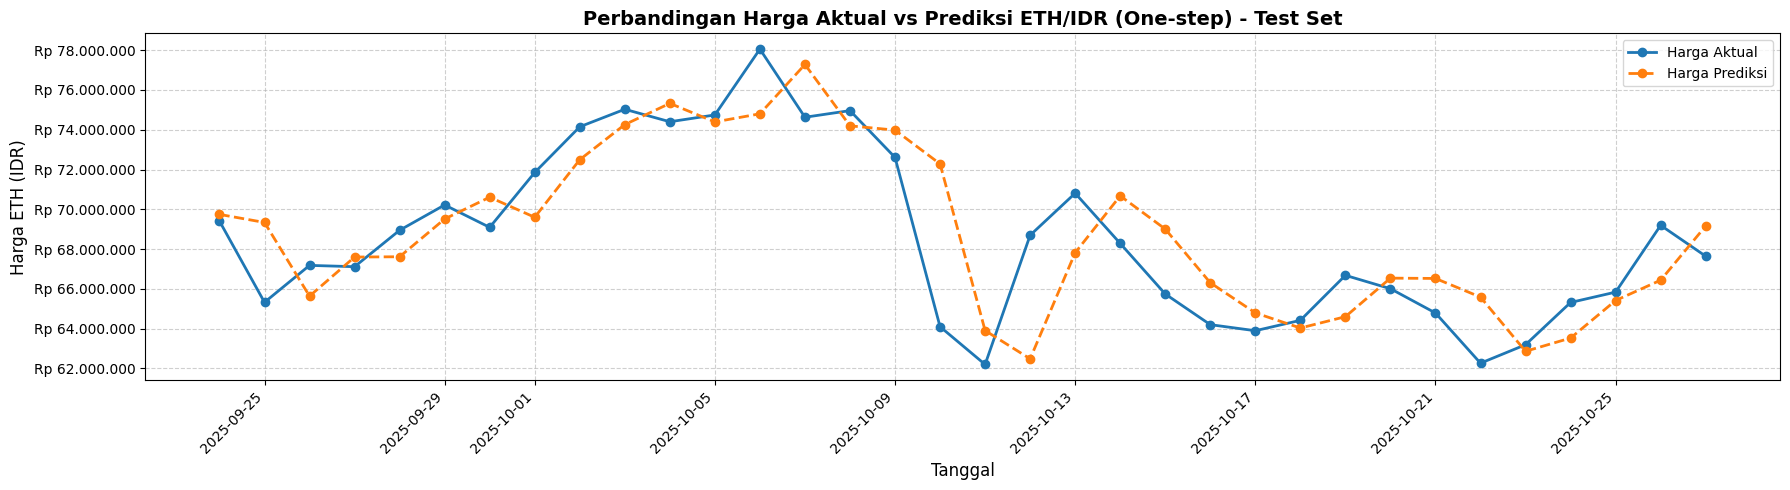

In [6]:

# --- Tanggal untuk test selaras dengan t+1 ---
plot_dates_full = pd.to_datetime(eth_processed["date"]).reset_index(drop=True).iloc[split_index+1:]

# Samakan panjang
min_len = min(len(plot_dates_full), len(close_t1_test_actual), len(pred_close_t1_test))

df_plot = pd.DataFrame({
    "Tanggal": plot_dates_full.iloc[:min_len].to_numpy(),
    "Harga Aktual": close_t1_test_actual.iloc[:min_len].to_numpy(),
    "Harga Prediksi": pd.Series(pred_close_t1_test).iloc[:min_len].to_numpy()
})

# --- Formatter Rupiah ---
def rupiah(x, pos):
    return f"Rp {x:,.0f}".replace(",", ".")

# --- Plot ---
plt.figure(figsize=(18, 5))

plt.plot(df_plot["Tanggal"], df_plot["Harga Aktual"],
         linewidth=2, marker='o', label="Harga Aktual")

plt.plot(df_plot["Tanggal"], df_plot["Harga Prediksi"],
         linewidth=2, linestyle='--', marker='o', label="Harga Prediksi")

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(rupiah))
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45, ha='right')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga ETH (IDR)", fontsize=12)
plt.title("Perbandingan Harga Aktual vs Prediksi ETH/IDR (One-step) - Test Set",
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


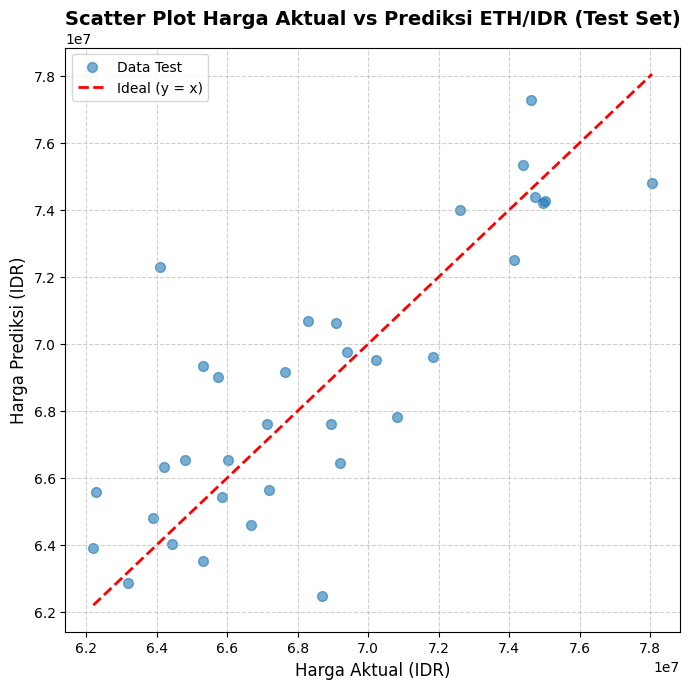

In [7]:
# Scatter: Actual vs Predicted

plt.figure(figsize=(7, 7))

plt.scatter(
    df_plot["Harga Aktual"],
    df_plot["Harga Prediksi"],
    alpha=0.6,
    s=50,
    label="Data Test"
)

# Garis ideal y = x
min_price = min(df_plot["Harga Aktual"].min(), df_plot["Harga Prediksi"].min())
max_price = max(df_plot["Harga Aktual"].max(), df_plot["Harga Prediksi"].max())
plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Ideal (y = x)"
)

plt.xlabel("Harga Aktual (IDR)", fontsize=12)
plt.ylabel("Harga Prediksi (IDR)", fontsize=12)
plt.title(
    "Scatter Plot Harga Aktual vs Prediksi ETH/IDR (Test Set)",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


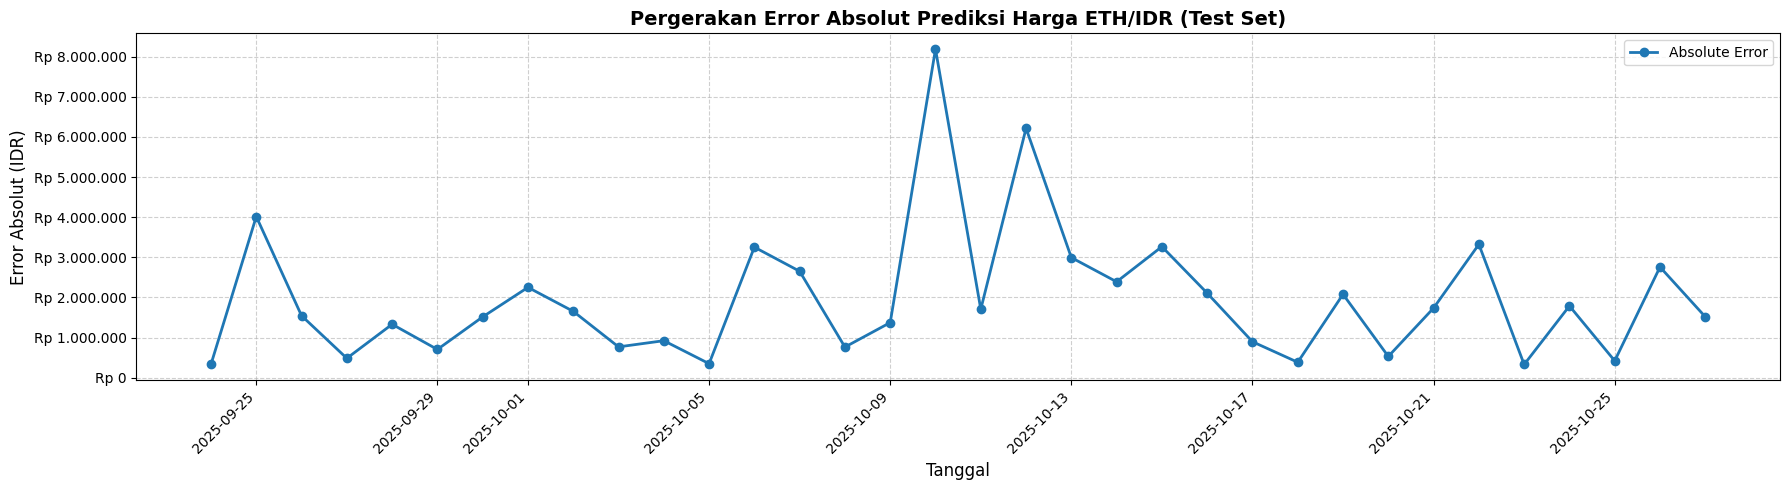

In [8]:
# Error Over Time
df_plot["Absolute Error"] = np.abs(
    df_plot["Harga Aktual"] - df_plot["Harga Prediksi"]
)

def rupiah(x, pos):
    return f"Rp {x:,.0f}".replace(",", ".")

plt.figure(figsize=(18, 5))

plt.plot(
    df_plot["Tanggal"],
    df_plot["Absolute Error"],
    linewidth=2,
    marker='o',
    label="Absolute Error"
)

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(rupiah))

plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Error Absolut (IDR)", fontsize=12)
plt.title(
    "Pergerakan Error Absolut Prediksi Harga ETH/IDR (Test Set)",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_10306/808844796.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


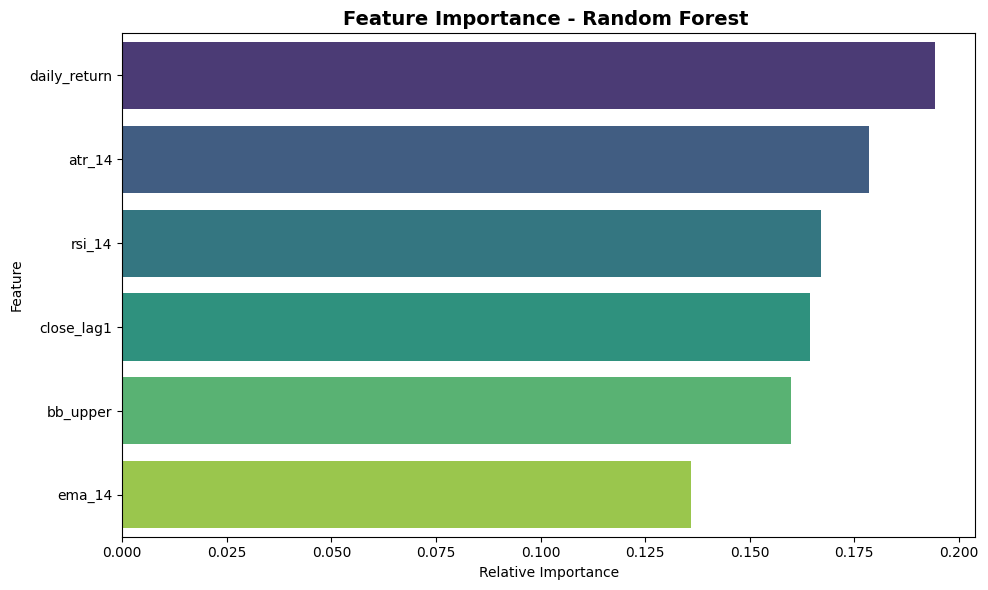


=== Feature Importance ===
     Feature  Importance
daily_return    0.194206
      atr_14    0.178417
      rsi_14    0.166952
  close_lag1    0.164476
    bb_upper    0.159879
      ema_14    0.136069


In [9]:
# === Feature Importance ===
importances = model.feature_importances_
feature_names = X.columns

fi_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature",
    orient="h",
    palette="viridis"
)
plt.title(
    "Feature Importance - Random Forest ",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\n=== Feature Importance ===")
print(fi_df.to_string(index=False))


# Conclusion

Model Evaluation Interpretation

The dataset was split using a 90:10 ratio, where 90% of the data was used for training and 10% for testing.

On the training set, the Random Forest model achieved an R² score of 0.988, indicating that the model explains 98.8% of the variance in the training data. This shows that the model effectively captures historical price patterns.

On the testing set, the model obtained an R² score of 0.628. Although lower than the training score, this result still indicates moderate predictive capability on unseen data. The decrease suggests some degree of overfitting, which is common in financial time-series modeling.

The Mean Absolute Percentage Error (MAPE) on the test set is 2.89%, indicating that the average prediction error is relatively small compared to the actual price values. Considering the high volatility of cryptocurrency markets, this performance can be considered satisfactory.

# Check (checking for data leakage)


Data Leakage and Robustness Validation

To ensure the reliability and integrity of the predictive model, several robustness tests were conducted to detect potential data leakage and validate performance consistency. These tests include feature shifting to prevent the use of future information, comparison against a naive baseline model, random target validation to detect memorization behavior, and intentional future-feature insertion to simulate leakage scenarios. Together, these evaluations confirm that the model captures meaningful patterns rather than relying on unintended data leakage.

In [12]:
X_shifted = X.copy()
X_shifted[:] = X_shifted.shift(1)

# Buang NaN
X_shifted = X_shifted.dropna()
y_aligned = y.loc[X_shifted.index]

model.fit(X_shifted.iloc[:split_index], y_aligned.iloc[:split_index])
y_pred_shifted = model.predict(X_shifted.iloc[split_index:])

print("R2 feature shift:", r2_score(y_aligned.iloc[split_index:], y_pred_shifted))



R2 feature shift: 0.03821200709074535


In [15]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

close = eth_processed["close"].reset_index(drop=True)

# Baseline: prediksi close_{t+1} = close_t
baseline_pred = close.shift(1)

baseline_pred_test = baseline_pred.iloc[split_index+1:]
actual_test        = close.iloc[split_index+1:]

df_base = pd.DataFrame({"actual": actual_test, "pred": baseline_pred_test}).dropna()
baseline_mae = mean_absolute_error(df_base["actual"], df_base["pred"])

# MAE Model: dari prediksi harga test kamu
model_mae = mean_absolute_error(close_t1_test_actual, pred_close_t1_test)

print("MAE Baseline:", baseline_mae)
print("MAE Model   :", model_mae)



MAE Baseline: 2010415.8844117653
MAE Model   : 1957994.442695834


In [13]:
y_random = y.sample(frac=1, random_state=42).values

model.fit(X_train, y_random[:len(X_train)])
y_pred_rand = model.predict(X_test)

print("R2 Random target :", r2_score(y_test, y_pred_rand))


R2 Random target : -0.13732153893835242


In [14]:
X_peek = X.copy()
X_peek["future_close"] = eth_processed["close"].shift(-1)

X_peek = X_peek.dropna()
y_peek = y.loc[X_peek.index]

model.fit(X_peek.iloc[:split_index], y_peek.iloc[:split_index])
y_pred_peek = model.predict(X_peek.iloc[split_index:])

print("R2 Future Feature:", r2_score(y_peek.iloc[split_index:], y_pred_peek))


R2 Future Feature: 0.10198819042345408


# Feature Distribution Scatterplot

This section visualizes the relationship between selected technical indicators and the target return variable. The scatter plots help observe potential correlations and patterns before model training.

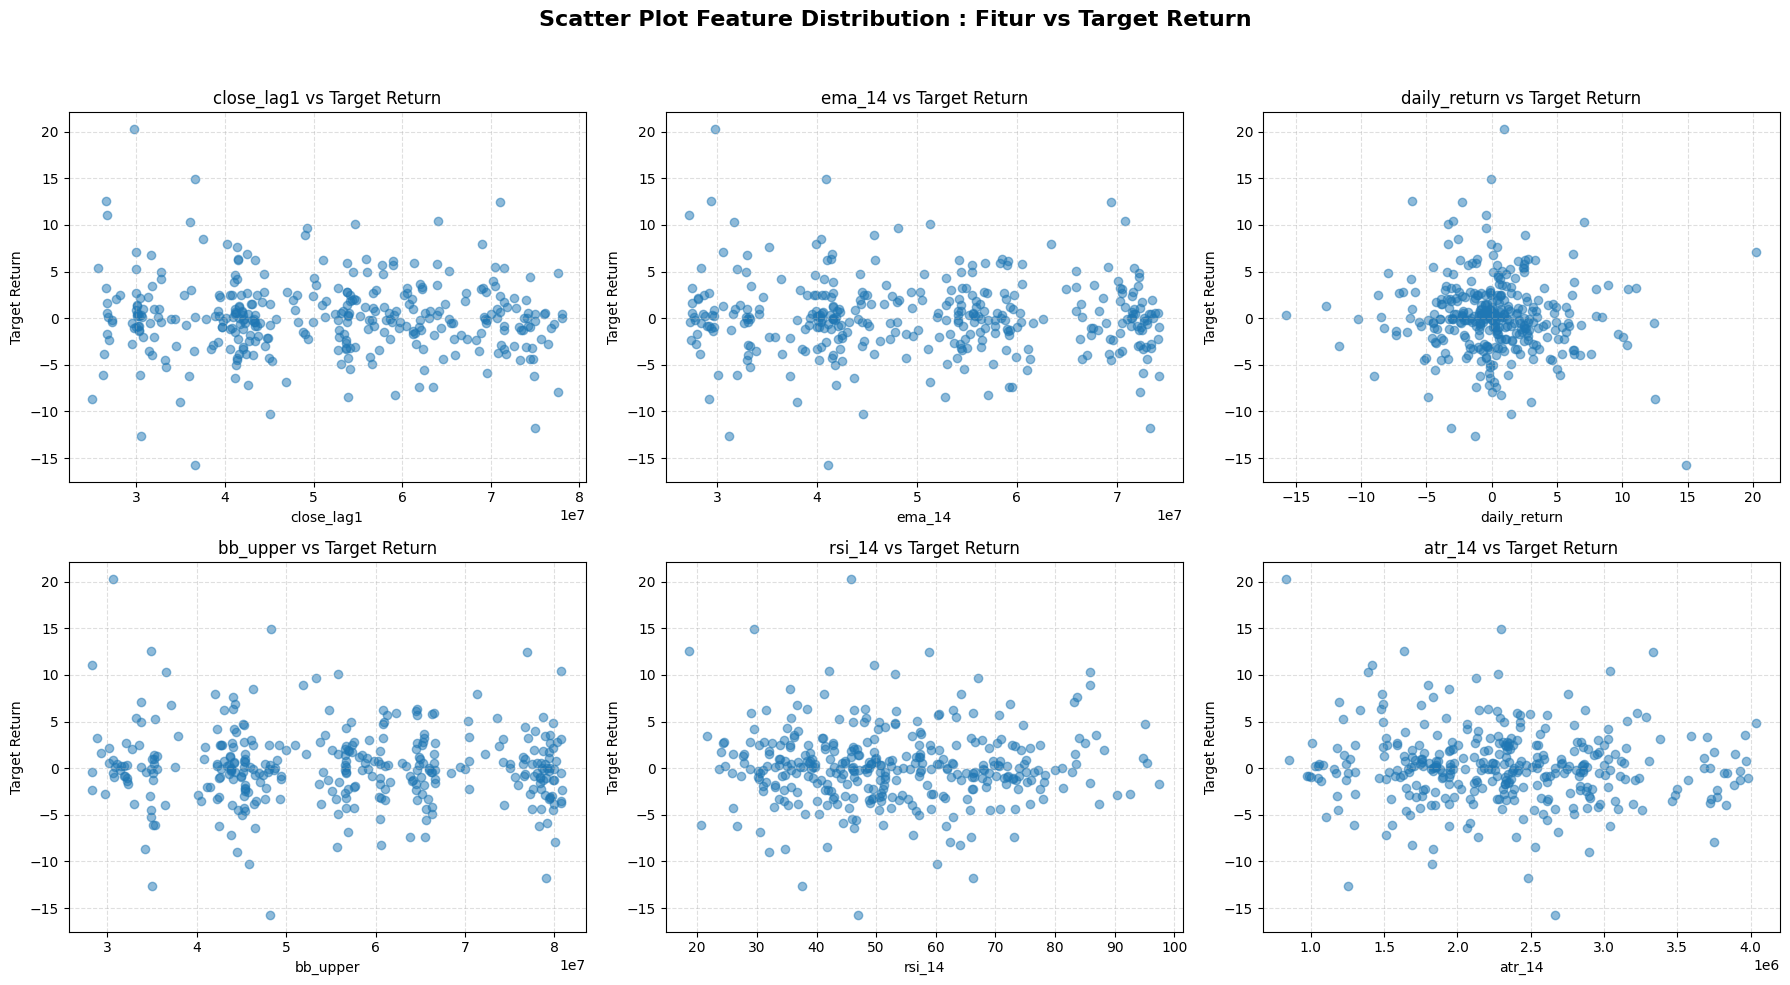

In [11]:
features = ['close_lag1', 'ema_14', 'daily_return', 'bb_upper', 'rsi_14', 'atr_14']
target = 'target_return'

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(
        eth_processed[feature],
        eth_processed[target],
        alpha=0.5
    )
    plt.xlabel(feature)
    plt.ylabel("Target Return")
    plt.title(f"{feature} vs Target Return")
    plt.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    "Scatter Plot Feature Distribution : Fitur vs Target Return",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


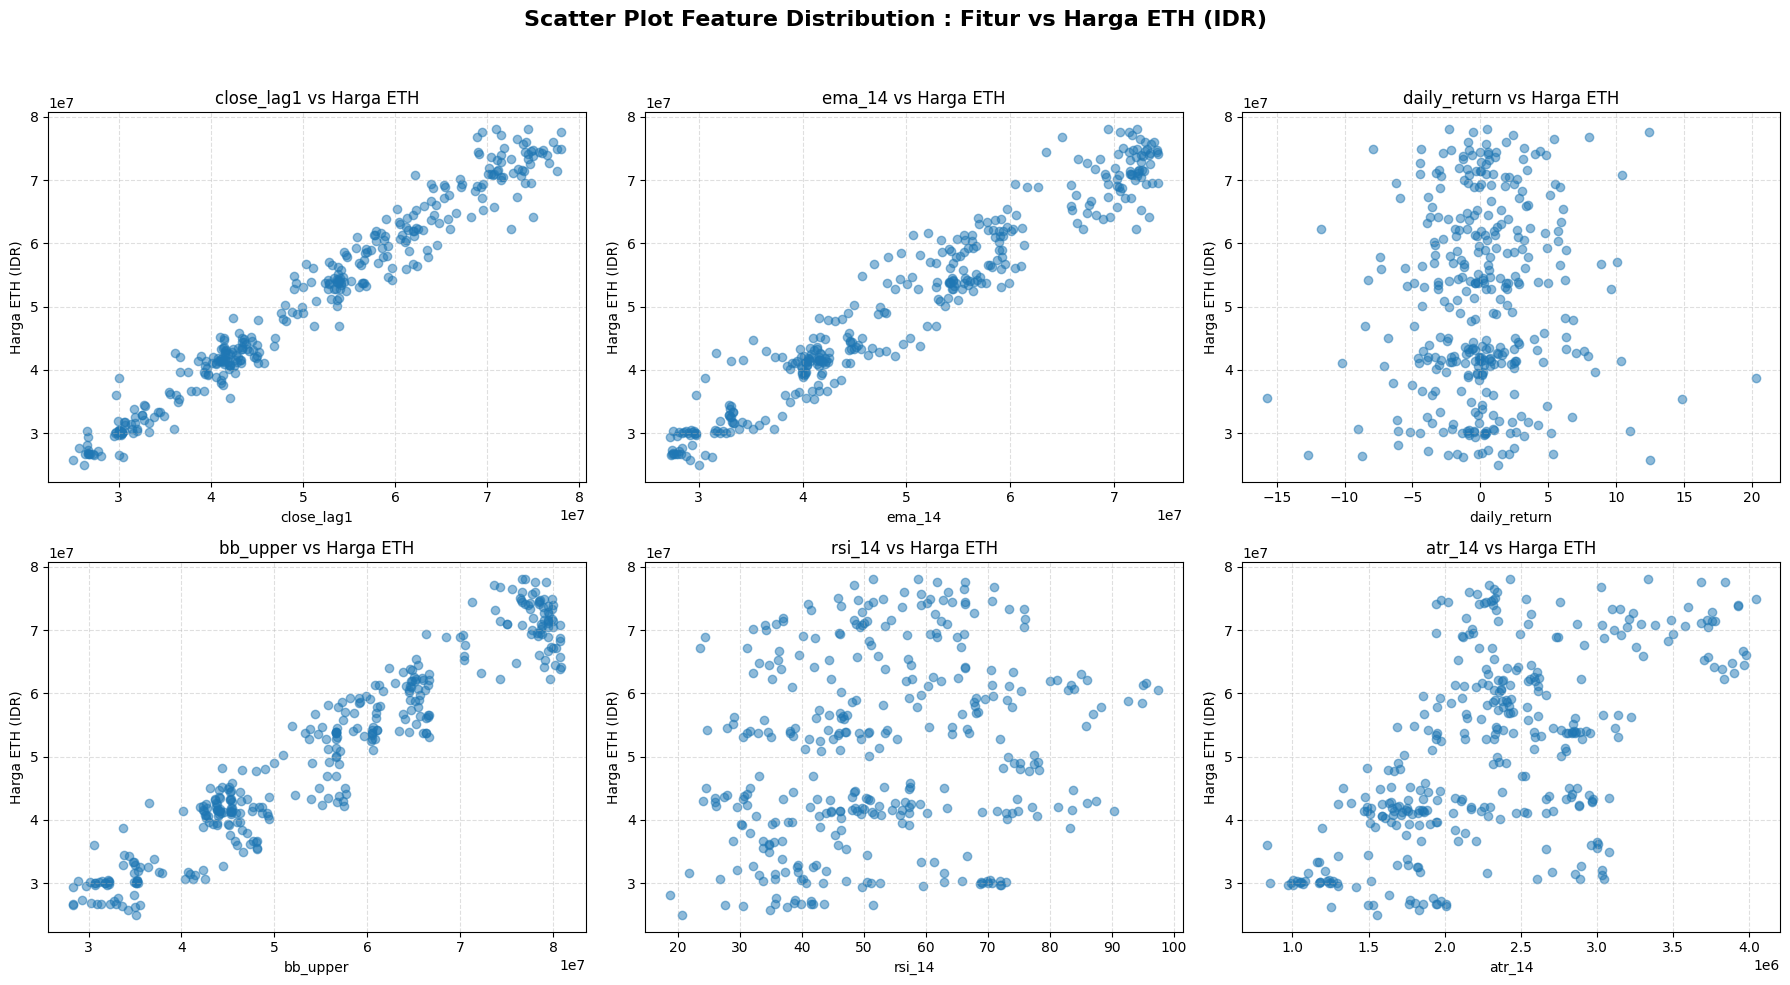

In [10]:
# Target (close t+1)
eth_processed["target_price"] = eth_processed["close"].shift(-1)


df_price = eth_processed.dropna().reset_index(drop=True)

features = ['close_lag1', 'ema_14', 'daily_return', 'bb_upper', 'rsi_14', 'atr_14']
target = 'target_price'

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(
        df_price[feature],
        df_price[target],
        alpha=0.5
    )
    plt.xlabel(feature)
    plt.ylabel("Harga ETH (IDR)")
    plt.title(f"{feature} vs Harga ETH")
    plt.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    "Scatter Plot Feature Distribution : Fitur vs Harga ETH (IDR)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
